/bin/sh: 1: SUSTech-HGEMM/scripts/benchmark.sh: not found


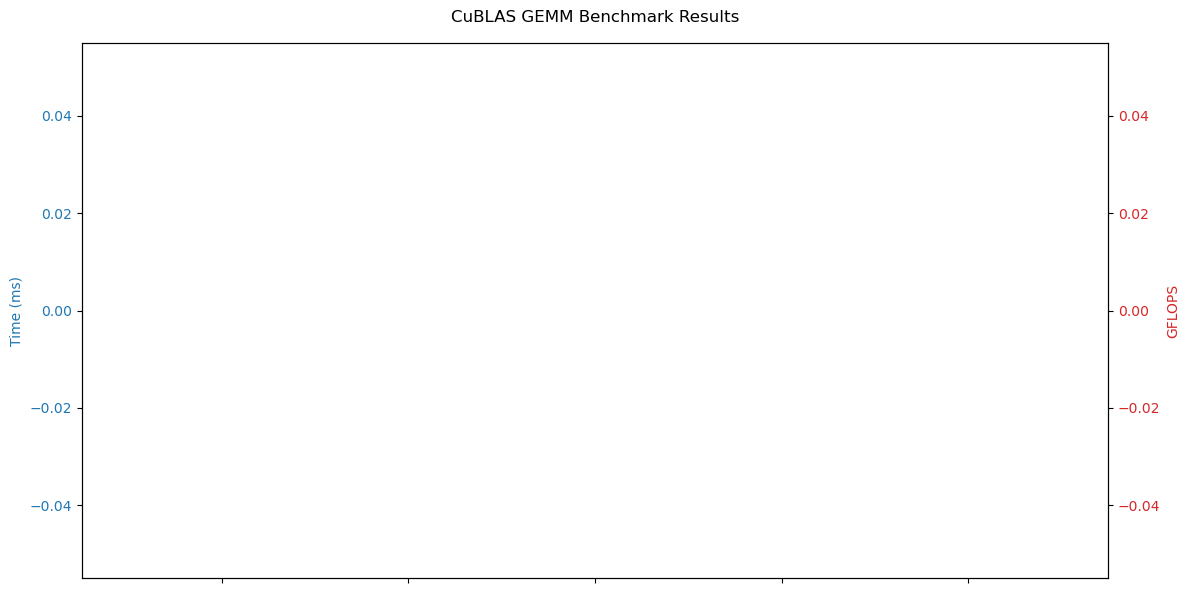

In [ ]:
# benchmark_run_and_plot.ipynb

import subprocess
import re
import matplotlib.pyplot as plt

# bash脚本名
benchmark_script = "../scripts/benchmark.sh"

def run_benchmark_and_parse(script_path):
    """
    运行benchmark脚本，捕获stdout，解析时间和GFLOPS信息
    返回列表：[{"case":..., "M":..., "N":..., "K":..., "time_ms":..., "gflops":..., "result_sum":...}, ...]
    """
    proc = subprocess.Popen(script_path, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    output_lines = []
    while True:
        line = proc.stdout.readline()
        if not line:
            break
        print(line, end="")  # 同时打印运行日志
        output_lines.append(line)
    proc.wait()

    pattern_case = re.compile(r"Running (\w+) with M=(\d+) N=(\d+) K=(\d+)")
    pattern_time = re.compile(r"CuBLAS GEMM Time: ([\d\.]+) ms, gFLOPS: ([\d\.]+)")
    pattern_sum = re.compile(r"Result sum: ([\d\.e\+\-]+)")

    results = []
    current_case = None

    for line in output_lines:
        m_case = pattern_case.search(line)
        if m_case:
            current_case = {
                "case": m_case.group(1),
                "M": int(m_case.group(2)),
                "N": int(m_case.group(3)),
                "K": int(m_case.group(4)),
                "time_ms": None,
                "gflops": None,
                "result_sum": None,
            }
            results.append(current_case)
            continue

        if current_case:
            m_time = pattern_time.search(line)
            if m_time:
                current_case["time_ms"] = float(m_time.group(1))
                current_case["gflops"] = float(m_time.group(2))
                continue

            m_sum = pattern_sum.search(line)
            if m_sum:
                current_case["result_sum"] = float(m_sum.group(1))
                continue

    return results

def plot_results(results):
    cases = [r['case'] for r in results]
    times = [r['time_ms'] for r in results]
    gflops = [r['gflops'] for r in results]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.bar(cases, times, color='tab:blue', alpha=0.6, label='Time (ms)')
    ax1.set_ylabel('Time (ms)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xticklabels(cases, rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(cases, gflops, color='tab:red', marker='o', label='GFLOPS')
    ax2.set_ylabel('GFLOPS', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    fig.suptitle("CuBLAS GEMM Benchmark Results")
    fig.tight_layout()
    plt.show()

# 运行脚本并解析
results = run_benchmark_and_parse(benchmark_script)

# 画图
plot_results(results)
